In [38]:
# Install all the Python libraries required for this project.
# Run this cell only if these libraries are not already installed.

!pip install pandas numpy matplotlib seaborn scikit-learn nltk joblib streamlit

     ---------------------------------------- 1.5/1.5 MB 19.2 MB/s eta 0:00:00
     -------------------------------------- 269.6/269.6 kB 8.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [42]:
# Load the spam dataset.
# The dataset contains two columns:
# label   -> ham or spam
# message -> actual SMS/email text


df = pd.read_csv("C:/Users/Bhumika gs/ML Projects/Spam Email Detection/Data/spam.csv", encoding="latin-1")

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [41]:
"""df = pd.read_csv(
    "C:/Users/Bhumika gs/ML Projects/Spam Email Detection/Data/spam.csv",
    sep="\t",
    header=None,
    names=["label", "message"]
)"""

'df = pd.read_csv(\n    "C:/Users/Bhumika gs/ML Projects/Spam Email Detection/Data/spam.csv",\n    sep="\t",\n    header=None,\n    names=["label", "message"]\n)'

In [44]:
# Important: if your CSV has columns like v1 and v2, we'll rename them

df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

df = df[["label", "message"]]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [45]:
# Check the data 

print(df.shape)
print(df.info())
print(df["label"].value_counts())

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
ham     4825
spam     747
Name: label, dtype: int64


In [46]:
# Convert the labels:

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [47]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
# TF-IDF

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [49]:
# Train Logistic Regression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [50]:
# Evaluate the model

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.968609865470852

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



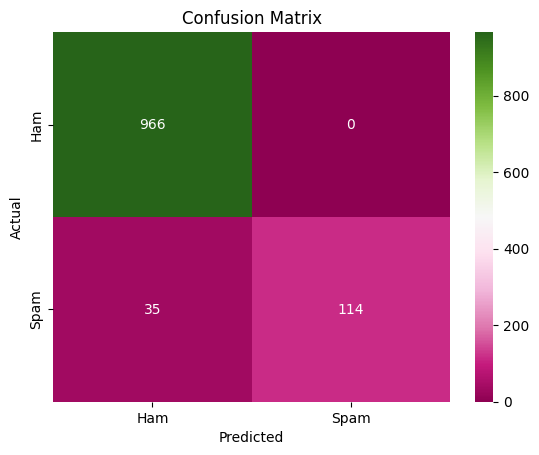

In [55]:
# Plot a Confusion matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    cmap='PiYG',
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [57]:
#Test your own message

message = ["Congratulations! You have won a free prize. Click now!"]

message_tfidf = tfidf.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("🚨 Spam")
else:
    print("✅ Not Spam")

🚨 Spam


In [58]:
# Save both the model and TF-IDF vectorizer

joblib.dump(model, "C:/Users/Bhumika gs/ML Projects/Spam Email Detection/models/spam_model.pkl")
joblib.dump(tfidf, "C:/Users/Bhumika gs/ML Projects/Spam Email Detection/models/tfidf_vectorizer.pkl")

['C:/Users/Bhumika gs/ML Projects/Spam Email Detection/models/tfidf_vectorizer.pkl']

In [62]:
# 1. Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.968609865470852


In [63]:
# 2. Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9713004484304932


In [64]:
# 3. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.97847533632287


In [65]:
# Compare the Models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.968610
1,Naive Bayes,0.971300
2,Random Forest,0.978475


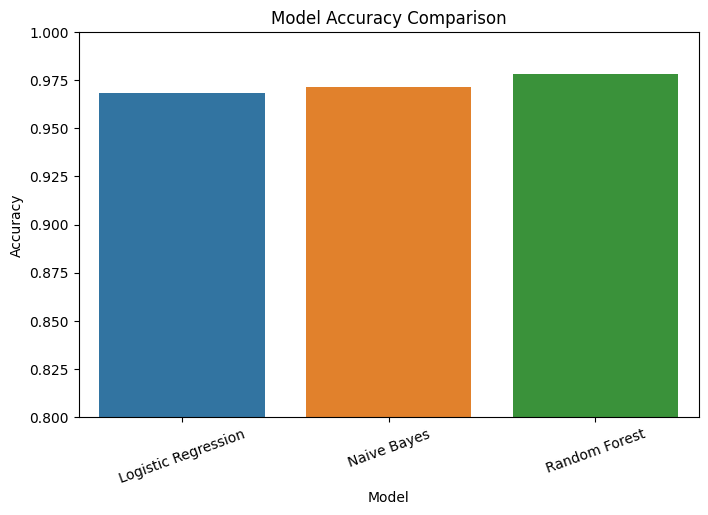

In [66]:
# visualize it:

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20)
plt.show()

In [67]:
# Checking precision, recall and F1-score

from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Naive Bayes")
print(classification_report(y_test, nb_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

Naive Bayes
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98     